In [2]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
df = pd.read_csv("izban_data.csv")

In [4]:
df.head()

,date_hours,time_of_day,day_of_week,weekend,station,heat,rains_mm,density_class
0,2025-05-01 00:00:00,0,3,0,Alsancak,20.5,0.0,Sakin
1,2025-05-01 01:00:00,1,3,0,Alsancak,32.2,0.0,Normal
2,2025-05-01 02:00:00,2,3,0,Alsancak,3.9,0.0,Sakin
3,2025-05-01 03:00:00,3,3,0,Alsancak,24.4,7.1,Normal
4,2025-05-01 04:00:00,4,3,0,Bayraklı,22.3,0.0,Sakin


In [5]:
df = df.drop("date_hours", axis=1)

In [6]:
df.head()

,time_of_day,day_of_week,weekend,station,heat,rains_mm,density_class
0,0,3,0,Alsancak,20.5,0.0,Sakin
1,1,3,0,Alsancak,32.2,0.0,Normal
2,2,3,0,Alsancak,3.9,0.0,Sakin
3,3,3,0,Alsancak,24.4,7.1,Normal
4,4,3,0,Bayraklı,22.3,0.0,Sakin


In [7]:
le_station = LabelEncoder()

In [8]:
df["station"] = le_station.fit_transform(df["station"])

In [9]:
le_target = LabelEncoder()

In [10]:
df["density_class"] = le_target.fit_transform(df["density_class"])

In [11]:
df.head()

,time_of_day,day_of_week,weekend,station,heat,rains_mm,density_class
0,0,3,0,0,20.5,0.0,1
1,1,3,0,0,32.2,0.0,0
2,2,3,0,0,3.9,0.0,1
3,3,3,0,0,24.4,7.1,0
4,4,3,0,1,22.3,0.0,1


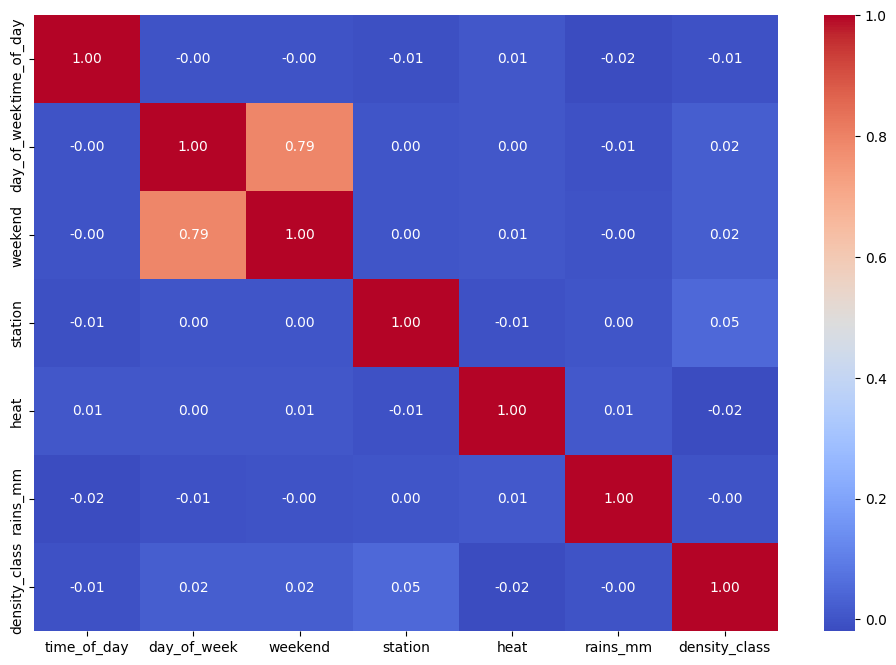

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [13]:
X = df.drop("density_class", axis=1)
y = df["density_class"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
scaler = StandardScaler()

In [16]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Ranadom Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Ridge": RidgeClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

In [18]:
import warnings
warnings.filterwarnings('ignore') 

In [19]:
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    print(f"{name}: Accuracy = {scores.mean():.4f}")

Logistic Regression: Accuracy = 0.6838
Decision Tree: Accuracy = 0.8550
Ranadom Forest: Accuracy = 0.8947
Gradient Boosting: Accuracy = 0.9062
Ridge: Accuracy = 0.6842
XGBoost: Accuracy = 0.9068
LightGBM: Accuracy = 0.9001


In [20]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [21]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

In [22]:
results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted")
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print(results_df)

               Model  Accuracy  Precision    Recall  F1 Score
1  Gradient Boosting  0.899543   0.896057  0.899543  0.896578
0            XGBoost  0.889269   0.885530  0.889269  0.886460
2           LightGBM  0.888699   0.885321  0.888699  0.886309


In [23]:
from sklearn.metrics import classification_report

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    print(f"\n{'='*50}")
    print(name)
    print('='*50)

    print(classification_report(y_test, y_pred))


XGBoost
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       458
           1       0.92      0.97      0.95      1177
           2       0.77      0.68      0.72       117

    accuracy                           0.89      1752
   macro avg       0.84      0.80      0.81      1752
weighted avg       0.89      0.89      0.89      1752


Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       458
           1       0.93      0.98      0.95      1177
           2       0.78      0.68      0.73       117

    accuracy                           0.90      1752
   macro avg       0.85      0.81      0.83      1752
weighted avg       0.90      0.90      0.90      1752


LightGBM
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       458
           1       0.93      0.96      0.94      1177
           2       0.76      0.69    

In [24]:
gb_model = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

In [25]:
random_search = RandomizedSearchCV(estimator=gb_model, param_distributions=param_grid, n_iter=50, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)

In [26]:
random_search.fit(X_train_scaled, y_train)
print("Best Params:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Best Params:
{'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5, 'learning_rate': 0.01}

Best CV Score:
0.9113870162030178
